<a href="https://colab.research.google.com/github/molluIdontknow/ELE_Algorithm/blob/%EA%B9%80%EB%AF%BC%EC%A0%9C/ELEalgo_MLP_battery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ELEalgo MLP — Battery SOH (배포 feature set)

`ELEalgo_MLP` 뼈대를 배터리 데이터에 맞게 수정한 버전.

**기존 뼈대 대비 변경점**
1. **셀 단위 split** — `train_test_split` → `GroupShuffleSplit` / `GroupKFold` (같은 셀이 train·test에 걸치면 누설)
2. **Feature set 고정** — 배포 가능한 것만 (`ccct`·`range`·`stdev`·ΔQ·`dcir_soc*` 제외)
3. **5-fold CV** — 141행에 단일 split은 테스트 셀 5개라 편차가 큼
4. **epoch·batch** — 20 → 2000 (early stopping), batch 100 → 16
5. **RF baseline** — 같은 fold로 비교해 MLP 학습 설정 문제인지 데이터 문제인지 구분
6. **조건별 RMSE** — 전체 평균이 특정 조건의 실패를 가리는 것 방지
7. **Export** — scaler 파라미터 + weight → Firmware/FPGA 전달용
8. **int8 양자화 전후 비교** — FPGA Fixed-Point 영향 사전 확인


# Config

In [3]:
import os, json, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

CONFIG = {
    "batch_size": 16,
    "epochs": 2000,
    "learning_rate": 0.003,
    "weight_decay": 1e-4,
    "patience": 100,        # early stopping
    "lr_patience": 30,      # ReduceLROnPlateau
    "n_folds": 5,
    "test_size": 0.2,
    "random_seed": 42,
}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
set_seed(CONFIG["random_seed"])
torch.set_num_threads(2)

# Dataset Load / Feature 설정

`FEATURE_SET`으로 어느 세트를 쓸지 고른다.

| 세트 | 내용 | 용도 |
|---|---|---|
| `deploy` | 보드에서 측정 가능한 것만 | **최종 모델** |
| `deploy_no_cvct` | cvct 제외 (60°C 부호역전 검증 전까지 안전판) | 비교 |
| `bench_paper` | 논문 ΔQ 계열 (0.2C 필요, 배포 불가) | 벤치마크 |
| `all25` | 전부 (ccct 누설 포함) | 참고용. **발표에 쓰지 말 것** |


In [4]:
# Colab: Drive에 올려둔 경우
DRIVE_PATH = "/content/drive/MyDrive/merged_features_25C.csv"
LOCAL_PATH = "merged_features_25C.csv"

if os.path.exists(DRIVE_PATH):
    CSV_FILENAME = DRIVE_PATH
elif os.path.exists(LOCAL_PATH):
    CSV_FILENAME = LOCAL_PATH
else:
    from google.colab import drive
    drive.mount("/content/drive")
    CSV_FILENAME = DRIVE_PATH

FEATURE_SETS = {
    "deploy":         ["dcirohm", "deltat103840", "cvct"],
    "deploy_no_cvct": ["dcirohm", "deltat103840"],
    "bench_paper":    ["variance", "xmean", "mean3839", "mean3940", "mean4041", "mean4142", "max", "min"],
    "all25":          ["variance","xmean","mean3839","mean3940","mean4041","mean4142","max","min","range","stdev",
                       "dcirohm","dcir_soc00ohm","dcir_soc10ohm","dcir_soc20ohm","dcir_soc30ohm","dcir_soc40ohm",
                       "dcir_soc50ohm","dcir_soc60ohm","dcir_soc70ohm","dcir_soc80ohm",
                       "deltat023840","deltat103840","ctr","ccct","cvct"],
}
FEATURE_SET = "deploy"          # <- 여기서 선택
FEATURES = FEATURE_SETS[FEATURE_SET]
TARGET = "soh_label_pct"
GROUP = "cell_global_id"

df = pd.read_csv(CSV_FILENAME, encoding="utf-8-sig")
df["cond"] = df["aging_condition"].str.replace(r"\s*#\d+$", "", regex=True)

X_all = df[FEATURES].values.astype(np.float32)
y_all = df[TARGET].values.astype(np.float32)
g_all = df[GROUP].values

print("Feature set:", FEATURE_SET, FEATURES)
print("전체 데이터:", len(df), "행 /", df[GROUP].nunique(), "셀")
print(df["cond"].value_counts().to_string())

Feature set: deploy ['dcirohm', 'deltat103840', 'cvct']
전체 데이터: 141 행 / 24 셀
cond
LOW C@ 25°C     57
4.35V@ 25°C     24
HIGH C@ 25°C    22
1V@ 25°C        20
4.5V@ 25°C      18


# Dataset Split — 셀 단위

**행이 아니라 셀로 나눈다.** 같은 셀의 RPT가 train·test에 같이 들어가면 모델이 그 셀의 궤적을 외워서 성능이 부풀려진다.

- Holdout test: 셀의 20% (최종 평가 1회)
- 나머지 80%: `GroupKFold(5)`로 CV (모델 선택·early stopping)


In [5]:
gss = GroupShuffleSplit(n_splits=1, test_size=CONFIG["test_size"], random_state=CONFIG["random_seed"])
dev_idx, test_idx = next(gss.split(X_all, y_all, groups=g_all))

X_dev, y_dev, g_dev = X_all[dev_idx], y_all[dev_idx], g_all[dev_idx]
X_test, y_test, g_test = X_all[test_idx], y_all[test_idx], g_all[test_idx]

print(f"Dev : {len(X_dev)} rows / {len(np.unique(g_dev))} cells")
print(f"Test: {len(X_test)} rows / {len(np.unique(g_test))} cells  ->", sorted(np.unique(g_test)))

Dev : 109 rows / 19 cells
Test: 32 rows / 5 cells  -> [np.int64(1), np.int64(9), np.int64(12), np.int64(17), np.int64(19)]


# MLP 모델 (N → 16 → 8 → 1)

In [6]:
class BatteryCSVDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

class SOHPredictorMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8),         nn.ReLU(),
            nn.Linear(8, 1),
        )
    def forward(self, x): return self.network(x)

def count_params(m): return sum(p.numel() for p in m.parameters())
print("파라미터 수:", count_params(SOHPredictorMLP(len(FEATURES))))

파라미터 수: 209


# 학습 함수

- Loss: MSE / Optimizer: Adam + weight decay
- ReduceLROnPlateau + Early stopping (val 기준)
- **타깃 스케일링**: SOH(80~100)를 그대로 쓰면 초기 loss가 수천이라 학습이 느림 → `(y − 90) / 10`로 변환해 학습, 평가 시 되돌림


In [7]:
Y_OFFSET, Y_SCALE = 90.0, 10.0
def y_enc(y): return (y - Y_OFFSET) / Y_SCALE
def y_dec(z): return z * Y_SCALE + Y_OFFSET

def train_mlp(X_tr, y_tr, X_va, y_va, verbose=False):
    scaler = StandardScaler().fit(X_tr)
    Xtr, Xva = scaler.transform(X_tr), scaler.transform(X_va)
    tr_loader = DataLoader(BatteryCSVDataset(Xtr, y_enc(y_tr)), batch_size=CONFIG["batch_size"], shuffle=True)
    Xva_t = torch.tensor(Xva, dtype=torch.float32); yva_t = torch.tensor(y_enc(y_va), dtype=torch.float32).unsqueeze(1)

    model = SOHPredictorMLP(X_tr.shape[1])
    crit = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=CONFIG["lr_patience"])

    best, best_state, wait = float("inf"), None, 0
    hist = {"train": [], "val": []}
    for ep in range(1, CONFIG["epochs"] + 1):
        model.train(); tl = 0
        for bx, by in tr_loader:
            opt.zero_grad(); loss = crit(model(bx), by); loss.backward(); opt.step(); tl += loss.item()
        tl /= len(tr_loader)
        model.eval()
        with torch.no_grad(): vl = crit(model(Xva_t), yva_t).item()
        sched.step(vl); hist["train"].append(tl); hist["val"].append(vl)
        if vl < best - 1e-6:
            best, wait = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if verbose and ep % 100 == 0: print(f"  ep {ep:4d}  train {tl:.4f}  val {vl:.4f}")
        if wait >= CONFIG["patience"]: break
    model.load_state_dict(best_state)
    return model, scaler, hist, ep

def predict(model, scaler, X):
    model.eval()
    with torch.no_grad():
        z = model(torch.tensor(scaler.transform(X), dtype=torch.float32)).numpy().flatten()
    return y_dec(z)

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))

# 5-fold CV (셀 단위) — MLP vs Random Forest

같은 fold에서 RF를 돌려 **성능 상한**을 잰다.
MLP가 RF보다 크게 나쁘면 데이터가 아니라 학습 설정 문제.


In [8]:
gkf = GroupKFold(n_splits=CONFIG["n_folds"])
cv = []
for k, (tr, va) in enumerate(gkf.split(X_dev, y_dev, groups=g_dev), 1):
    set_seed(CONFIG["random_seed"] + k)
    model, scaler, hist, ep = train_mlp(X_dev[tr], y_dev[tr], X_dev[va], y_dev[va])
    r_mlp = rmse(y_dev[va], predict(model, scaler, X_dev[va]))
    rf = RandomForestRegressor(n_estimators=200, random_state=CONFIG["random_seed"], n_jobs=-1).fit(X_dev[tr], y_dev[tr])
    r_rf = rmse(y_dev[va], rf.predict(X_dev[va]))
    cv.append({"fold": k, "val_cells": len(np.unique(g_dev[va])), "epochs": ep, "MLP_RMSE": r_mlp, "RF_RMSE": r_rf})
    print(f"fold {k}: MLP {r_mlp:.3f}  RF {r_rf:.3f}  (stopped @ {ep})")

cv_df = pd.DataFrame(cv)
print()
print(f"MLP  5-fold RMSE: {cv_df.MLP_RMSE.mean():.3f} ± {cv_df.MLP_RMSE.std():.3f} %SOH")
print(f"RF   5-fold RMSE: {cv_df.RF_RMSE.mean():.3f} ± {cv_df.RF_RMSE.std():.3f} %SOH")

fold 1: MLP 1.016  RF 0.987  (stopped @ 200)
fold 2: MLP 1.592  RF 1.925  (stopped @ 239)
fold 3: MLP 0.961  RF 1.920  (stopped @ 137)
fold 4: MLP 3.515  RF 3.458  (stopped @ 177)
fold 5: MLP 1.267  RF 0.891  (stopped @ 113)

MLP  5-fold RMSE: 1.670 ± 1.061 %SOH
RF   5-fold RMSE: 1.836 ± 1.032 %SOH


# 최종 학습 (Dev 전체) → Holdout Test

In [9]:
# dev 안에서 val 셀 20%를 early stopping용으로 분리
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=CONFIG["random_seed"] + 99)
tr2, va2 = next(gss2.split(X_dev, y_dev, groups=g_dev))
set_seed(CONFIG["random_seed"])
model, scaler, hist, ep = train_mlp(X_dev[tr2], y_dev[tr2], X_dev[va2], y_dev[va2], verbose=True)

pred_test = predict(model, scaler, X_test)
print()
print(f"Holdout Test RMSE: {rmse(y_test, pred_test):.3f} %SOH   MAE: {mean_absolute_error(y_test, pred_test):.3f}   (stopped @ {ep})")
torch.save(model.state_dict(), "best_mlp_model.pth")

  ep  100  train 0.0096  val 0.1230

Holdout Test RMSE: 1.455 %SOH   MAE: 1.109   (stopped @ 142)


# Loss Curve

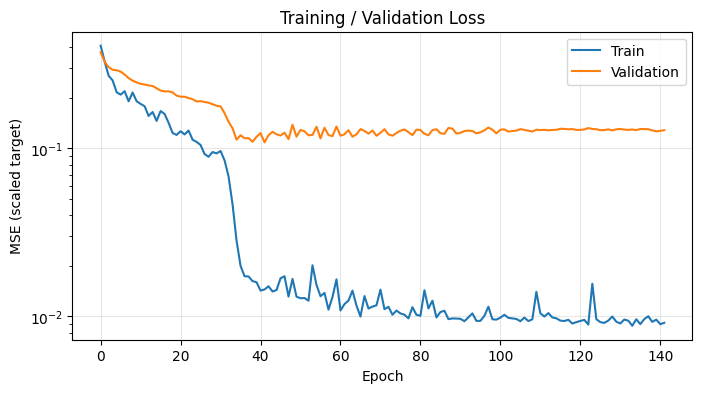

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(hist["train"], label="Train"); plt.plot(hist["val"], label="Validation")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled target)")
plt.title("Training / Validation Loss"); plt.legend(); plt.grid(alpha=.3); plt.show()

# Actual vs Predicted + 조건별 RMSE

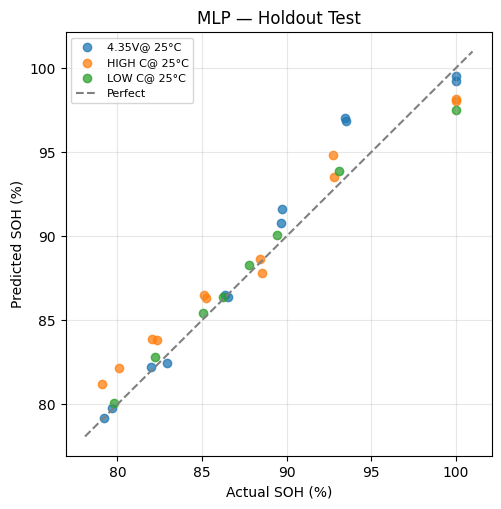

조건별 / 셀별 RMSE (test)
                               n   RMSE  max_abs_err
cond         cell_global_id                         
4.35V@ 25°C  17              6.0  1.588        3.356
             19              6.0  1.564        3.568
HIGH C@ 25°C 9               6.0  1.735        2.102
             12              6.0  1.417        2.044
LOW C@ 25°C  1               8.0  0.991        2.459


/tmp/ipykernel_476/3399769809.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(test_df.groupby(["cond", GROUP]).apply(lambda d: pd.Series({


In [11]:
test_df = df.iloc[test_idx].copy()
test_df["pred"] = pred_test
test_df["abs_err"] = (test_df[TARGET] - test_df["pred"]).abs()

plt.figure(figsize=(5.5, 5.5))
for c, gdf in test_df.groupby("cond"):
    plt.scatter(gdf[TARGET], gdf["pred"], alpha=.75, label=c)
lo, hi = test_df[TARGET].min() - 1, test_df[TARGET].max() + 1
plt.plot([lo, hi], [lo, hi], "--", color="gray", label="Perfect")
plt.xlabel("Actual SOH (%)"); plt.ylabel("Predicted SOH (%)"); plt.title("MLP — Holdout Test")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.show()

print("조건별 / 셀별 RMSE (test)")
print(test_df.groupby(["cond", GROUP]).apply(lambda d: pd.Series({
    "n": len(d), "RMSE": rmse(d[TARGET], d["pred"]), "max_abs_err": d["abs_err"].max()})).round(3).to_string())

# Export — Firmware / FPGA 전달용

- `scaler_params.json`: feature별 mean / std → **Firmware가 정규화에 쓰는 상수 테이블**
- `mlp_weights_float.json`: float32 weight/bias (layer별)
- 정규화: `x_norm = (x − mean) / std`, 출력 복원: `SOH = z × 10 + 90`


In [12]:
scaler_params = {
    "features": FEATURES,
    "mean": scaler.mean_.tolist(),
    "std": scaler.scale_.tolist(),
    "y_offset": Y_OFFSET, "y_scale": Y_SCALE,
}
with open("scaler_params.json", "w") as f: json.dump(scaler_params, f, indent=2)

weights = {}
for name, p in model.state_dict().items():
    weights[name] = p.numpy().tolist()
with open("mlp_weights_float.json", "w") as f: json.dump(weights, f)

print(json.dumps(scaler_params, indent=2))
print({k: np.array(v).shape for k, v in weights.items()})

{
  "features": [
    "dcirohm",
    "deltat103840",
    "cvct"
  ],
  "mean": [
    0.02628774726546781,
    754.854260111964,
    479.98779083961665
  ],
  "std": [
    0.0028132667036851215,
    44.17028021484581,
    27.877107359656375
  ],
  "y_offset": 90.0,
  "y_scale": 10.0
}
{'network.0.weight': (16, 3), 'network.0.bias': (16,), 'network.2.weight': (8, 16), 'network.2.bias': (8,), 'network.4.weight': (1, 8), 'network.4.bias': (1,)}


# int8 양자화 전후 비교 (Post-Training, per-tensor symmetric)

FPGA Fixed-Point Spec(weight int8, activation int16, shift scale) 영향을 미리 본다.
weight를 int8로 양자화한 뒤 다시 float으로 되돌려 같은 test에 추론 → RMSE 차이 = 양자화 손실.


In [13]:
def quantize_int8_symmetric(w):
    s = np.max(np.abs(w)) / 127.0 if np.max(np.abs(w)) > 0 else 1.0
    q = np.clip(np.round(w / s), -127, 127).astype(np.int8)
    return q, s

q_state, q_meta = {}, {}
for name, p in model.state_dict().items():
    w = p.numpy()
    if name.endswith("weight"):
        q, s = quantize_int8_symmetric(w)
        q_state[name] = torch.tensor(q.astype(np.float32) * s)
        q_meta[name] = {"scale": float(s), "int8": q.tolist()}
    else:
        q_state[name] = p.clone()          # bias는 float 유지 (FPGA에서 int32 accumulator)
        q_meta[name] = {"float": w.tolist()}

qmodel = SOHPredictorMLP(len(FEATURES)); qmodel.load_state_dict(q_state)
pred_q = predict(qmodel, scaler, X_test)

print(f"float32 Test RMSE : {rmse(y_test, pred_test):.3f}")
print(f"int8-w  Test RMSE : {rmse(y_test, pred_q):.3f}")
print(f"max |float - int8| : {np.max(np.abs(pred_test - pred_q)):.3f} %SOH")

with open("mlp_weights_int8.json", "w") as f: json.dump(q_meta, f)

float32 Test RMSE : 1.455
int8-w  Test RMSE : 1.450
max |float - int8| : 0.026 %SOH


# Golden Test Vector (FPGA 검증용)

test 셋의 정규화된 입력 + float 출력 + int8 출력을 CSV로 저장.
FPGA RTL 시뮬레이션 결과와 이 파일을 bit-level 비교한다.


In [14]:
gv = pd.DataFrame(scaler.transform(X_test), columns=[f"x_{f}" for f in FEATURES])
gv["soh_actual"] = y_test
gv["soh_pred_float"] = pred_test
gv["soh_pred_int8w"] = pred_q
gv.to_csv("golden_test_vectors.csv", index=False)
print(gv.head().round(4).to_string(index=False))
print("\n저장: scaler_params.json, mlp_weights_float.json, mlp_weights_int8.json, golden_test_vectors.csv, best_mlp_model.pth")

 x_dcirohm  x_deltat103840  x_cvct  soh_actual  soh_pred_float  soh_pred_int8w
   -1.2082          0.8712 -1.3250  100.000000       97.540604       97.539299
   -0.7737          0.7202 -0.8946   93.108002       93.862701       93.861801
   -0.4182          0.3429 -0.7834   89.463203       90.078697       90.071701
   -0.0628          0.2297 -0.6937   87.773399       88.305298       88.296402
    0.2137          0.0033 -0.1538   86.249199       86.370903       86.362396

저장: scaler_params.json, mlp_weights_float.json, mlp_weights_int8.json, golden_test_vectors.csv, best_mlp_model.pth
